# FZI-AURA - Context, Vehicle State, and Temporal Trajectories

This notebook builds one framework-neutral, end-to-end-driving-style sample from FZI-AURA. It combines:

- six synchronized surround-camera views
- road and weather context
- synchronized vehicle state
- dense past and future ego positions
- sparse trajectories of other traffic participants using scene-unique object IDs
- the realized future ego path projected into the current `front_medium` image

Vehicle state, poses, context, and boxes require `base_keyframes`. The camera mosaic and trajectory overlay additionally require `camera_keyframes` and are skipped when that layer is not installed.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from fzi_aura import FZIAURADataset
from fzi_aura.errors import SceneNotFoundError

os.environ["FZI_AURA_ROOT"] = "/data/fzi-aura"

DATASET_ROOT = Path(
    os.environ.get(
        "FZI_AURA_ROOT",
        "/path/to/dataset_export",
    )
)

dataset = FZIAURADataset(DATASET_ROOT)


def layer_installed(layer):
    return dataset.available_layers is None or layer in dataset.available_layers


camera_keyframes_installed = layer_installed("camera_keyframes")
print(f"Scenes: {len(dataset)}")

Scenes: 2473


## 1. Select an Informative Anchor Frame

This curated example provides two seconds of history, future data, with a pronounced turn, multiple tracked traffic participants, and a `front_medium` view.

In [2]:
HISTORY_FRAMES = 20
FUTURE_FRAMES = 40
CAMERA_ID = "front_medium"
EXAMPLE_SCENE_IDS = ["2025-07-02-15-35-20|140", "2025-06-11-14-31-00|37"]
EXAMPLE_ANCHOR_LOCAL_INDEX = 95

for scene_id in EXAMPLE_SCENE_IDS:
    try:
        scene = dataset.get_scene(scene_id)
        break
    except SceneNotFoundError:
        continue
else:
    raise RuntimeError(
        f"None of the curated example scenes {EXAMPLE_SCENE_IDS!r} "
        "are installed in the dataset."
    )
anchor_local_index = EXAMPLE_ANCHOR_LOCAL_INDEX
if not (HISTORY_FRAMES <= anchor_local_index < len(scene) - FUTURE_FRAMES):
    raise RuntimeError(
        "The curated anchor does not have the requested temporal context."
    )
anchor_frame = scene[anchor_local_index]
anchor_signals = anchor_frame.load_vehicle_signals_row()
anchor_from_future = anchor_frame.relative_ego_pose(FUTURE_FRAMES)
future_heading_change_deg = float(
    np.rad2deg(np.arctan2(anchor_from_future[1, 0], anchor_from_future[0, 0]))
)

{
    "scene_id": scene.scene_id,
    "anchor_local_index": anchor_local_index,
    "anchor_frame_index": anchor_frame.frame_index,
    "anchor_timestamp_ns": anchor_frame.timestamp_ns,
    "speed_kph": float(anchor_signals["speed_kph"]),
    "future_position_xy_m": anchor_from_future[:2, 3],
    "future_heading_change_deg": future_heading_change_deg,
    "front_medium_available": anchor_frame.has_camera(CAMERA_ID),
}

{'scene_id': '2025-07-02-15-35-20|140',
 'anchor_local_index': 95,
 'anchor_frame_index': 95,
 'anchor_timestamp_ns': 1751473355800000000,
 'speed_kph': 35.2400016784668,
 'future_position_xy_m': array([ 34.06909673, -13.64384588]),
 'future_heading_change_deg': -48.50566667172766,
 'front_medium_available': True}

## 2. Inspect Six Synchronized Camera Views

FZI-AURA provides eight camera streams. This example selects six surround views, similar to the multi-camera configurations commonly used in 3D perception and BEV-based models. `front_wide` and `front_tele` remain available for other model designs.

In [3]:
SURROUND_CAMERA_IDS = (
    "left_forward",
    "front_medium",
    "right_forward",
    "left_rearward",
    "rear_wide",
    "right_rearward",
)
missing_cameras = [
    sensor for sensor in SURROUND_CAMERA_IDS if not anchor_frame.has_camera(sensor)
]

if missing_cameras:
    print(f"Skipped: the anchor is missing camera views: {missing_cameras}")
    camera_images = {}
else:
    camera_images = {
        sensor: anchor_frame.load_camera(sensor) for sensor in SURROUND_CAMERA_IDS
    }

{
    "available_camera_sensors": anchor_frame.available_cameras(),
    "loaded_camera_shapes": {
        sensor: image.shape for sensor, image in camera_images.items()
    },
}

{'available_camera_sensors': ('front_medium',
  'front_tele',
  'front_wide',
  'left_forward',
  'left_rearward',
  'rear_wide',
  'right_forward',
  'right_rearward'),
 'loaded_camera_shapes': {'left_forward': (1200, 1920, 3),
  'front_medium': (1200, 1920, 3),
  'right_forward': (1200, 1920, 3),
  'left_rearward': (1200, 1920, 3),
  'rear_wide': (2048, 2592, 3),
  'right_rearward': (1200, 1920, 3)}}

#### Visualize the Camera Coverage

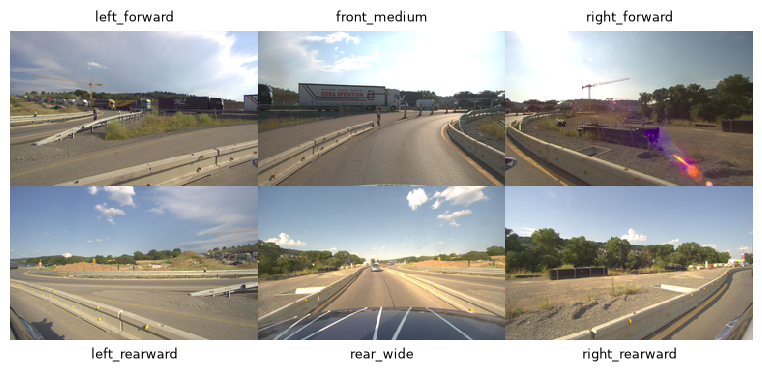

In [4]:
from PIL import Image

MOSAIC_CAMERA_LAYOUT = (
    ("left_forward", "front_medium", "right_forward"),
    ("left_rearward", "rear_wide", "right_rearward"),
)
MOSAIC_TILE_WIDTH = 256
MOSAIC_TILE_HEIGHT = 160
camera_tiles = {}

if camera_images:
    resampling = getattr(Image, "Resampling", Image).LANCZOS
    target_aspect = MOSAIC_TILE_WIDTH / MOSAIC_TILE_HEIGHT
    for sensor, loaded_image in camera_images.items():
        source = loaded_image
        source_height, source_width = source.shape[:2]
        source_aspect = source_width / source_height
        if source_aspect < target_aspect:
            crop_height = int(round(source_width / target_aspect))
            y0 = (source_height - crop_height) // 2
            source = source[y0 : y0 + crop_height]
        elif source_aspect > target_aspect:
            crop_width = int(round(source_height * target_aspect))
            x0 = (source_width - crop_width) // 2
            source = source[:, x0 : x0 + crop_width]
        camera_tiles[sensor] = np.asarray(
            Image.fromarray(source).resize(
                (MOSAIC_TILE_WIDTH, MOSAIC_TILE_HEIGHT),
                resample=resampling,
            )
        )

    mosaic = np.vstack(
        [
            np.hstack([camera_tiles[sensor] for sensor in row])
            for row in MOSAIC_CAMERA_LAYOUT
        ]
    )
    fig, axis = plt.subplots(figsize=(7.68, 3.52), dpi=100)
    axis.imshow(mosaic, interpolation="nearest")
    for column, sensor in enumerate(MOSAIC_CAMERA_LAYOUT[0]):
        axis.text(
            (column + 0.5) * MOSAIC_TILE_WIDTH,
            -7,
            sensor,
            ha="center",
            va="bottom",
            fontsize=9,
        )
    for column, sensor in enumerate(MOSAIC_CAMERA_LAYOUT[1]):
        axis.text(
            (column + 0.5) * MOSAIC_TILE_WIDTH,
            2 * MOSAIC_TILE_HEIGHT + 7,
            sensor,
            ha="center",
            va="top",
            fontsize=9,
        )
    axis.set_xlim(-0.5, mosaic.shape[1] - 0.5)
    axis.set_ylim(mosaic.shape[0] + 22, -22)
    axis.axis("off")
    fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0)
    plt.show()

## 3. Load Road, Weather, and Vehicle Context

Road and weather information is timestamp-aligned with the vehicle state in `ego/vehicle_signals.parquet`. Passing `columns=...` to  `load_vehicle_signals()` selects and loads only the necessary fields.

In [5]:
SIGNAL_COLUMNS = [
    "timestamp_ns",
    "speed_kph",
    "steering_angle",
    "steering_angle_rad",
    "ins_imu_linear_acceleration_x",
    "ins_imu_linear_acceleration_y",
    "ins_imu_linear_acceleration_z",
    "ins_imu_angular_velocity_x",
    "ins_imu_angular_velocity_y",
    "ins_imu_angular_velocity_z",
    "ins_odom_twist_linear_x",
    "ins_odom_twist_linear_y",
    "ins_odom_twist_linear_z",
    "indicator_light_left_on",
    "indicator_light_right_on",
    "road_type",
    "osm_highway_tag",
    "weather",
    "temp",
    "clouds",
    "wind_speed",
]
signals = scene.load_vehicle_signals(columns=SIGNAL_COLUMNS)
anchor_signal_index = np.flatnonzero(
    signals["timestamp_ns"].to_numpy(dtype=np.int64) == anchor_frame.timestamp_ns
)[0]
context_row = signals.iloc[anchor_signal_index]


# The weather field is the direct output of the OpenWeatherMap API, which is a list of weather conditions. https://openweathermap.org/api/weather-conditions
# We extract the first condition and use its "description" field (eg. "scattered clouds") or "main" field (eg. "Clouds") for our driving context.
def describe_weather(value):
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, list) and value:
        value = value[0]
    if isinstance(value, dict):
        return value.get("description") or value.get("main") or "unknown"
    return "unknown" if value is None else str(value)


driving_context = {
    "road_type": context_row["road_type"],
    "osm_highway_tag": context_row["osm_highway_tag"],
    "weather": describe_weather(context_row["weather"]),
    "temperature_c": float(context_row["temp"]),
    "cloud_cover_percent": float(context_row["clouds"]),
    "wind_speed_mps": float(context_row["wind_speed"]),
    "speed_kph": float(context_row["speed_kph"]),
    "steering_angle_deg": float(np.rad2deg(context_row["steering_angle_rad"])),
}
driving_context

{'road_type': 'motorway',
 'osm_highway_tag': 'motorway_link',
 'weather': 'scattered clouds',
 'temperature_c': 35.98,
 'cloud_cover_percent': 38.0,
 'wind_speed_mps': 1.49,
 'speed_kph': 35.2400016784668,
 'steering_angle_deg': -3.0057984872011234}

### Current E2E Ego-State Vector

E2E models commonly condition their prediction on the vehicle state at the current timestamp. The ordered vector below retains all three acceleration, angular-velocity, and linear-velocity axes plus steering.

In [6]:
EGO_STATUS_COLUMNS = (
    "ins_imu_linear_acceleration_x",
    "ins_imu_linear_acceleration_y",
    "ins_imu_linear_acceleration_z",
    "ins_imu_angular_velocity_x",
    "ins_imu_angular_velocity_y",
    "ins_imu_angular_velocity_z",
    "ins_odom_twist_linear_x",
    "ins_odom_twist_linear_y",
    "ins_odom_twist_linear_z",
    "steering_angle",
)
ego_status = context_row.loc[list(EGO_STATUS_COLUMNS)].to_numpy(dtype=np.float32)
ego_status_table = {
    column: float(value) for column, value in zip(EGO_STATUS_COLUMNS, ego_status)
}
{
    "shape": ego_status.shape,
    "ordered_values": ego_status,
    "fields": ego_status_table,
}

{'shape': (10,),
 'ordered_values': array([ 1.4080804e-02, -1.4352701e+00,  3.2109848e-01, -1.8419347e-03,
         1.0598558e-02, -1.6560704e-01,  9.8858662e+00,  7.9629324e-02,
        -8.9919150e-02, -5.2461080e-02], dtype=float32),
 'fields': {'ins_imu_linear_acceleration_x': 0.014080803841352463,
  'ins_imu_linear_acceleration_y': -1.435270071029663,
  'ins_imu_linear_acceleration_z': 0.3210984766483307,
  'ins_imu_angular_velocity_x': -0.0018419347470626235,
  'ins_imu_angular_velocity_y': 0.010598558001220226,
  'ins_imu_angular_velocity_z': -0.1656070351600647,
  'ins_odom_twist_linear_x': 9.885866165161133,
  'ins_odom_twist_linear_y': 0.0796293243765831,
  'ins_odom_twist_linear_z': -0.08991914987564087,
  'steering_angle': -0.05246108025312424}}

## 4. Inspect the Synchronized State Window

The vertical line marks the current image timestamp. Values to its left are available as history; values to its right are shown to explain the recorded motion and could be targets or evaluation data for a model.

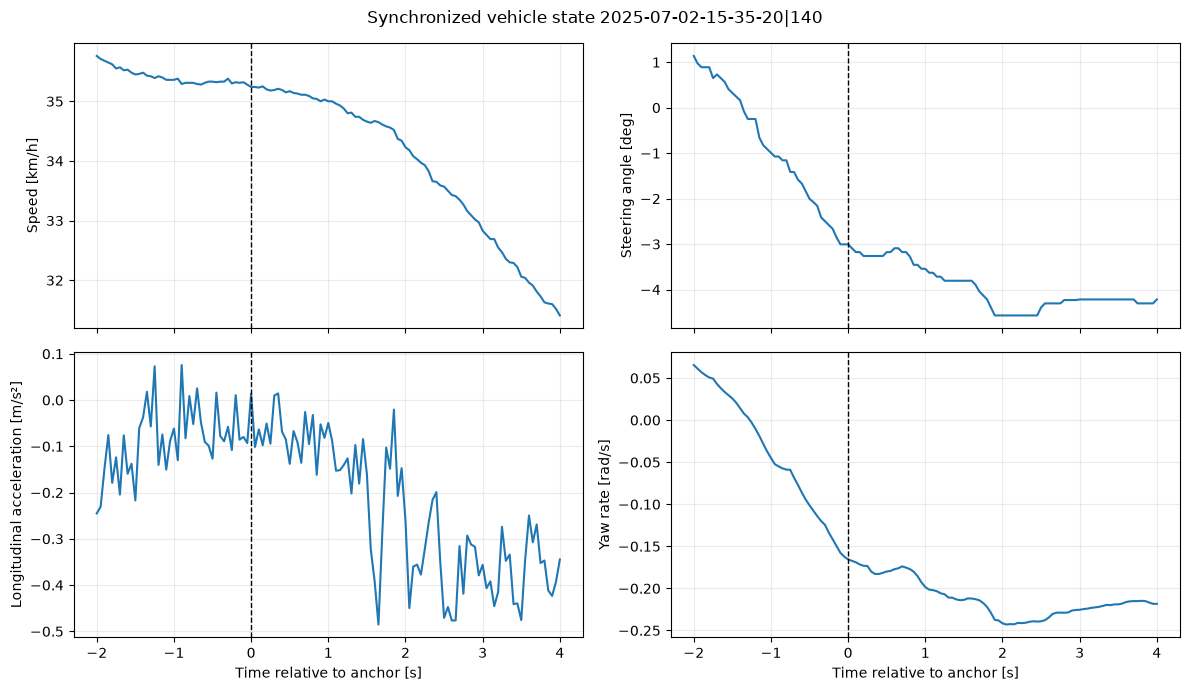

In [7]:
time_s = (
    signals["timestamp_ns"].to_numpy(dtype=np.int64) - anchor_frame.timestamp_ns
).astype(np.float64) * 1e-9
window_mask = (time_s >= -2.0) & (time_s <= 4.0)
window_time_s = time_s[window_mask]
window_signals = signals.loc[window_mask]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
plots = [
    ("speed_kph", "Speed [km/h]", 1.0),
    ("steering_angle_rad", "Steering angle [deg]", 180.0 / np.pi),
    ("ins_imu_linear_acceleration_x", "Longitudinal acceleration [m/s²]", 1.0),
    ("ins_imu_angular_velocity_z", "Yaw rate [rad/s]", 1.0),
]
for axis, (column, label, scale) in zip(axes.flat, plots):
    axis.plot(window_time_s, window_signals[column].to_numpy() * scale)
    axis.axvline(0.0, color="black", linestyle="--", linewidth=1)
    axis.set_ylabel(label)
    axis.grid(alpha=0.25)
for axis in axes[-1]:
    axis.set_xlabel("Time relative to anchor [s]")
fig.suptitle(f"Synchronized vehicle state {scene.scene_id}")
fig.tight_layout()
plt.show()

## 5. Ego and Traffic-Participant Trajectories in BEV

Ego poses are sampled densely at 10 Hz. Other participant centers come from sparse 3D-box keyframes and are grouped by their scene-unique `object_id`. `anchor_frame.object_trajectories(...)` moves every complete box from its time-local `base_link` coordinates into the anchor frame. We display every track with at least three observations that comes within 80 m of the anchor.

In [8]:
offsets = np.arange(-HISTORY_FRAMES, FUTURE_FRAMES + 1, dtype=np.int64)
trajectory_time_s = offsets / 10.0
ego_positions = anchor_frame.ego_trajectory(
    offsets.tolist(), target_frame="base_link", missing="nan"
)

transformed_tracks = anchor_frame.object_trajectories(
    offsets.tolist(), target_frame="base_link"
)
participant_tracks = []

for object_id, boxes in transformed_tracks.items():
    observations = [
        {
            "time_s": (box.timestamp_ns - anchor_frame.timestamp_ns) * 1e-9,
            "center_xyz": box.center,
            "category": box.category,
        }
        for box in boxes
    ]
    if len(observations) < 3:
        continue
    xy = np.asarray([item["center_xyz"][:2] for item in observations])
    closest_distance_m = float(np.linalg.norm(xy, axis=1).min())
    if closest_distance_m <= 80.0:
        participant_tracks.append(
            {
                "object_id": object_id,
                "category": observations[0]["category"],
                "time_s": np.asarray([item["time_s"] for item in observations]),
                "positions_xyz": np.asarray(
                    [item["center_xyz"] for item in observations]
                ),
                "closest_distance_m": closest_distance_m,
            }
        )

participant_tracks.sort(key=lambda item: item["closest_distance_m"])
print(f"Found {len(participant_tracks)} nearby participant tracks.")
# [(track["object_id"], track["category"], len(track["time_s"])) for track in participant_tracks]

Found 31 nearby participant tracks.


#### Visualize the Anchor-Frame Trajectories

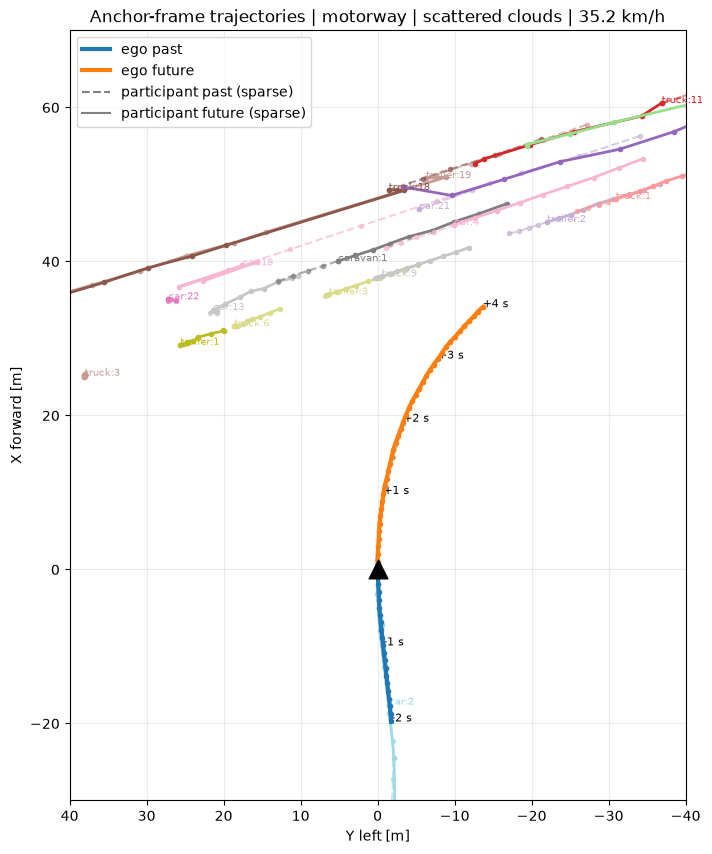

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
past_ego = trajectory_time_s <= 0.0
future_ego = trajectory_time_s >= 0.0
ax.plot(
    ego_positions[past_ego, 1],
    ego_positions[past_ego, 0],
    "o-",
    color="tab:blue",
    linewidth=3,
    markersize=3,
    zorder=4,
)
ax.plot(
    ego_positions[future_ego, 1],
    ego_positions[future_ego, 0],
    "o-",
    color="tab:orange",
    linewidth=3,
    markersize=3,
    zorder=4,
)
ax.scatter([0.0], [0.0], marker="^", s=180, color="black", zorder=5)

track_colors = plt.cm.tab20_r(np.linspace(0.0, 1.0, max(len(participant_tracks), 1)))
for color, track in zip(track_colors, participant_tracks):
    positions = track["positions_xyz"]
    times = track["time_s"]
    past = times <= 0.0
    future = times >= 0.0
    if past.any():
        ax.plot(
            positions[past, 1],
            positions[past, 0],
            "o--",
            color=color,
            alpha=0.65,
            markersize=3,
        )
    if future.any():
        ax.plot(
            positions[future, 1],
            positions[future, 0],
            "o-",
            color=color,
            linewidth=2,
            markersize=3,
        )
    nearest = int(np.argmin(np.abs(times)))
    ax.annotate(
        f"{track['object_id']}",
        (positions[nearest, 1], positions[nearest, 0]),
        fontsize=7,
        color=color,
    )

for offset in (-20, -10, 10, 20, 30, 40):
    row = int(np.flatnonzero(offsets == offset)[0])
    ax.annotate(
        f"{offset / 10:+.0f} s",
        (ego_positions[row, 1], ego_positions[row, 0]),
        fontsize=8,
    )

legend_items = [
    Line2D([0], [0], color="tab:blue", linewidth=3, label="ego past"),
    Line2D([0], [0], color="tab:orange", linewidth=3, label="ego future"),
    Line2D([0], [0], color="gray", linestyle="--", label="participant past (sparse)"),
    Line2D([0], [0], color="gray", linestyle="-", label="participant future (sparse)"),
]
ax.legend(handles=legend_items, loc="upper left")
ax.set_xlabel("Y left [m]")
ax.set_ylabel("X forward [m]")
# ROS base_link uses +Y to the vehicle's left, while a Matplotlib x-axis
# normally increases toward the screen's right. Reverse the horizontal
# limits so physical left also appears on the left side of the BEV.
ax.set_xlim(40, -40)
ax.set_ylim(-30, 70)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.set_title(
    f"Anchor-frame trajectories | {driving_context['road_type']} | "
    f"{driving_context['weather']} | {driving_context['speed_kph']:.1f} km/h"
)
plt.show()

## 6. Project the Realized Future Ego Path Into `front_medium`

The future path includes the anchor-frame origin `[0, 0, 0]` at `t=0`. The SDK calibration transforms these `base_link` points into the current camera frame and projects them into image coordinates.

In [10]:
image = None
future_path_camera = None
if not anchor_frame.has_camera(CAMERA_ID):
    print("Skipped: install camera_keyframes to show the front-camera trajectory.")
else:
    image = camera_images.get(CAMERA_ID)
    if image is None:
        image = anchor_frame.load_camera(CAMERA_ID)
    # Include the anchor itself: t=0 is [0, 0, 0] in anchor base_link.
    future = trajectory_time_s >= 0.0
    future_points_base = ego_positions[future]
    future_time_s = trajectory_time_s[future]

    calibration = anchor_frame.calibration()
    future_points_camera = calibration.transform_points(
        future_points_base, dst_frame=f"camera/{CAMERA_ID}", src_frame="base_link"
    )
    uv, depth = calibration.project_points(future_points_camera, CAMERA_ID)
    future_path_camera = {
        "uv": uv,
        "depth": depth,
        "time_s": future_time_s,
        "base_link_xyz": future_points_base,
    }

{
    "image_shape": None if image is None else image.shape,
    "base_link_path_shape": None
    if future_path_camera is None
    else future_path_camera["base_link_xyz"].shape,
    "projected_uv_shape": None
    if future_path_camera is None
    else future_path_camera["uv"].shape,
}

{'image_shape': (1200, 1920, 3),
 'base_link_path_shape': (41, 3),
 'projected_uv_shape': (41, 2)}

#### Visualize the Projected Path

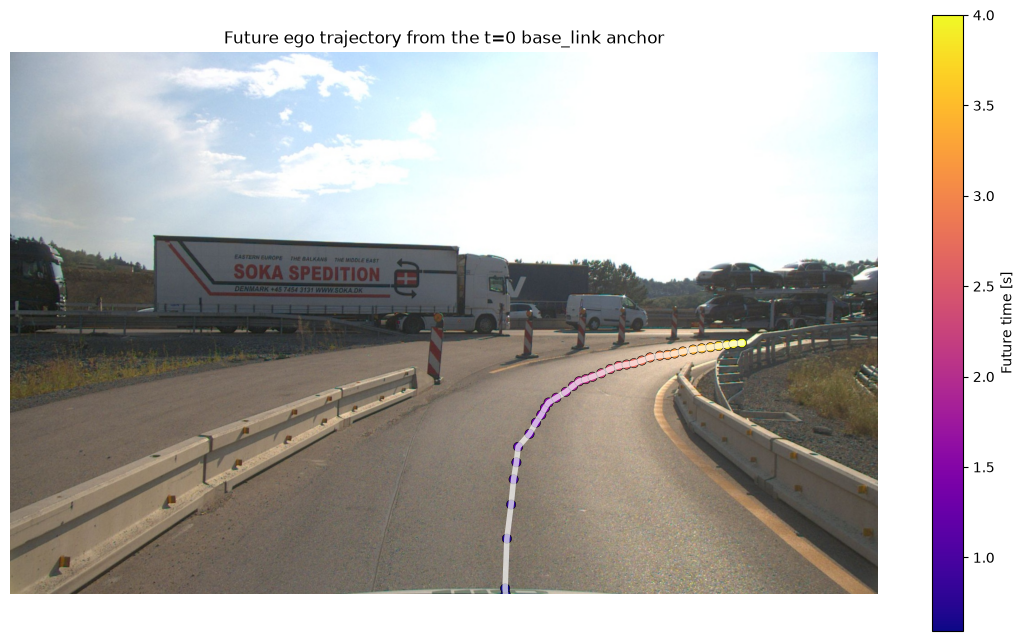

In [11]:
future_projection = None
if future_path_camera is not None:
    height, width = image.shape[:2]
    uv = future_path_camera["uv"]
    depth = future_path_camera["depth"]
    future_time_s = future_path_camera["time_s"]
    visible = (
        (depth > 0.0)
        & (uv[:, 0] >= 0.0)
        & (uv[:, 0] < width)
        & (uv[:, 1] >= 0.0)
        & (uv[:, 1] < height)
    )
    projected_uv = uv[visible]
    projected_depth = depth[visible]
    projected_time_s = future_time_s[visible]

    # The t=0 base_link origin is behind the front camera. Find the segment
    # where the physically projected path enters through the image bottom
    # and prepend that clipped boundary point for a continuous rendering.
    visible_indices = np.flatnonzero(visible)
    if len(visible_indices):
        first_visible = int(visible_indices[0])
        prior = np.flatnonzero(
            (np.arange(len(uv)) < first_visible)
            & (depth > 0.0)
            & np.isfinite(uv).all(axis=1)
        )
        if len(prior):
            previous = int(prior[-1])
            bottom = float(height - 1)
            uv_before = uv[previous]
            uv_after = uv[first_visible]
            if uv_before[1] > bottom >= uv_after[1]:
                alpha = (bottom - uv_before[1]) / (uv_after[1] - uv_before[1])
                entry_x = uv_before[0] + alpha * (uv_after[0] - uv_before[0])
                if 0.0 <= entry_x < width:
                    entry_time_s = future_time_s[previous] + alpha * (
                        future_time_s[first_visible] - future_time_s[previous]
                    )
                    entry_depth = depth[previous] + alpha * (
                        depth[first_visible] - depth[previous]
                    )
                    projected_uv = np.vstack([[entry_x, bottom], projected_uv])
                    projected_depth = np.r_[entry_depth, projected_depth]
                    projected_time_s = np.r_[entry_time_s, projected_time_s]

    future_projection = {
        "uv": projected_uv,
        "depth": projected_depth,
        "time_s": projected_time_s,
        "base_link_xyz": future_path_camera["base_link_xyz"],
        "base_link_time_s": future_path_camera["time_s"],
    }

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(image)
    ax.plot(
        future_projection["uv"][:, 0],
        future_projection["uv"][:, 1],
        color="white",
        linewidth=4,
        alpha=0.7,
    )
    scatter = ax.scatter(
        future_projection["uv"][:, 0],
        future_projection["uv"][:, 1],
        c=future_projection["time_s"],
        cmap="plasma",
        s=45,
        edgecolors="black",
        linewidths=0.4,
    )
    fig.colorbar(scatter, ax=ax, label="Future time [s]")
    ax.set_title("Future ego trajectory from the t=0 base_link anchor")
    ax.axis("off")
    plt.show()

## 7. Build a Temporal Training Sample

This cell collects the data prepared above into a single training sample:

* `observations_at_anchor` contains the camera images, current ego state, pose, and driving context.
* `optional_causal_history` contains ego and participant information from timestamps before `t=0`.
* `targets` contains the future ego trajectory and participant positions from `t=0` onward.

Participant tracks are kept as variable-length arrays because objects may enter or leave the scene and annotations may be sparse.
The final output shows the main array shapes and track counts so that the sample can be checked before it is passed to a training pipeline.


In [12]:
history_offsets = np.arange(-HISTORY_FRAMES, 1, dtype=np.int64)
history_state = []
for offset in history_offsets:
    row = scene[anchor_local_index + int(offset)].load_vehicle_signals_row()
    history_state.append(
        [
            float(row["speed_kph"]) / 3.6,
            float(row["steering_angle_rad"]),
            float(row["ins_imu_linear_acceleration_x"]),
            float(row["ins_imu_angular_velocity_z"]),
        ]
    )
history_state = np.asarray(history_state, dtype=np.float32)
# The future target convention includes the current anchor at t=0.
future_mask = trajectory_time_s >= 0.0
participant_history = []
participant_future = []
for track in participant_tracks:
    shared = {"object_id": track["object_id"], "category": track["category"]}
    history = track["time_s"] < 0.0
    future = track["time_s"] >= 0.0
    if history.any():
        participant_history.append(
            {
                **shared,
                "time_s": track["time_s"][history].astype(np.float32),
                "positions_xy_m": track["positions_xyz"][history, :2].astype(
                    np.float32
                ),
            }
        )
    if future.any():
        participant_future.append(
            {
                **shared,
                "time_s": track["time_s"][future].astype(np.float32),
                "positions_xy_m": track["positions_xyz"][future, :2].astype(np.float32),
            }
        )

temporal_sample = {
    "scene_id": scene.scene_id,
    "timestamp_ns": anchor_frame.timestamp_ns,
    "observations_at_anchor": {
        "camera_images": camera_images,
        "ego_status": ego_status,
        "ego_status_columns": EGO_STATUS_COLUMNS,
        "odom_from_base_link": anchor_frame.load_ego_pose().astype(np.float32),
        "context": driving_context,
    },
    "optional_causal_history": {
        "ego_history_xy_m": ego_positions[trajectory_time_s <= 0.0, :2].astype(
            np.float32
        ),
        "ego_history_state": history_state,
        "ego_history_state_columns": (
            "speed_mps",
            "steering_angle_rad",
            "acceleration_x_mps2",
            "yaw_rate_radps",
        ),
        "annotated_participant_history": participant_history,
    },
    "targets": {
        "ego_future_xy_m": ego_positions[future_mask, :2].astype(np.float32),
        "ego_future_time_s": trajectory_time_s[future_mask].astype(np.float32),
        "participant_future": participant_future,
    },
}

{
    "camera_shapes": {sensor: value.shape for sensor, value in camera_images.items()},
    "ego_status": temporal_sample["observations_at_anchor"]["ego_status"].shape,
    "ego_history_xy": temporal_sample["optional_causal_history"][
        "ego_history_xy_m"
    ].shape,
    "ego_history_state": temporal_sample["optional_causal_history"][
        "ego_history_state"
    ].shape,
    "ego_future_xy": temporal_sample["targets"]["ego_future_xy_m"].shape,
    "annotated_participant_history_tracks": len(
        temporal_sample["optional_causal_history"]["annotated_participant_history"]
    ),
    "participant_future_tracks": len(temporal_sample["targets"]["participant_future"]),
    "context": temporal_sample["observations_at_anchor"]["context"],
}

{'camera_shapes': {'left_forward': (1200, 1920, 3),
  'front_medium': (1200, 1920, 3),
  'right_forward': (1200, 1920, 3),
  'left_rearward': (1200, 1920, 3),
  'rear_wide': (2048, 2592, 3),
  'right_rearward': (1200, 1920, 3)},
 'ego_status': (10,),
 'ego_history_xy': (21, 2),
 'ego_history_state': (21, 4),
 'ego_future_xy': (41, 2),
 'annotated_participant_history_tracks': 30,
 'participant_future_tracks': 31,
 'context': {'road_type': 'motorway',
  'osm_highway_tag': 'motorway_link',
  'weather': 'scattered clouds',
  'temperature_c': 35.98,
  'cloud_cover_percent': 38.0,
  'wind_speed_mps': 1.49,
  'speed_kph': 35.2400016784668,
  'steering_angle_deg': -3.0057984872011234}}